In [59]:
#### Load Packages

In [2]:
%run "////home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/simulation/simulation_prereqs/impport_packages.ipynb"    #import all necessary packages - numpy, pandas etc
%run "////home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/simulation/simulation_prereqs/simulation_class.ipynb"    #import all necessary packages - numpy, pandas etc
%run "////home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/simulation/simulation_prereqs/create_world.ipynb"

#### Load Data

In [39]:
#epi results
# dims 1
file = '/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/results/new_results/diff_sp/epi/gens10000_dims1_mutrate0.001.pkl'
with open(file, "rb") as file:
            dim1_epi = pickle.load(file)
            
# dims 5
file = '/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/results/new_results/diff_sp/epi/gens10000_dims5_mutrate0.001.pkl'
with open(file, "rb") as file:
            dim5_epi = pickle.load(file)
            
#only-gen results
# dims 1
         
file = '/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/results/new_results/diff_sp/onlygen/gens10000_dims1_onlygen.pkl'
with open(file, "rb") as file:
            dim1_og = pickle.load(file)
            
# dims 5
file = '/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/results/new_results/diff_sp/onlygen/gens10000_dims5_onlygen.pkl'
with open(file, "rb") as file:
            dim5_og = pickle.load(file)

# dims 10
file = '/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/results/new_results/diff_sp/epi/gens10000_dims10_mutrate0.001.pkl'
with open(file, "rb") as file:
            dim10_epi = pickle.load(file)
            
#only-gen results
# dims 10
         
file = '/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/results/new_results/diff_sp/onlygen/gens10000_dims10_onlygen.pkl'
with open(file, "rb") as file:
            dim10_og = pickle.load(file)

In [40]:
keys = list(dim1_epi[0].keys())

concatenated_results_dim1_epi = {}
concatenated_results_dim5_epi = {}

for k in keys:
        concatenated_results_dim1_epi[k] = np.vstack([r[k] for r in dim1_epi])
        
for k in keys:
        concatenated_results_dim5_epi[k] = np.vstack([r[k] for r in dim5_epi])

concatenated_results_dim1_og = {}
concatenated_results_dim5_og = {}

for k in keys:
        concatenated_results_dim1_og[k] = np.vstack([r[k] for r in dim1_og])
        
for k in keys:
        concatenated_results_dim5_og[k] = np.vstack([r[k] for r in dim5_og])

In [41]:
initial_mem = np.arange(-3, 3.5, 0.5)
initial_mem

array([-3. , -2.5, -2. , -1.5, -1. , -0.5,  0. ,  0.5,  1. ,  1.5,  2. ,
        2.5,  3. ])

In [42]:
#Collect Dtaa
concatenated_results_epi = concatenated_results_dim1_epi
meanmemory_p = concatenated_results_epi['meanmemory_p'][:, :-1]
meanneutral_p = concatenated_results_epi['meanneutral_p'][:, :-1]
stdmemory_p = concatenated_results_epi['std_memory_p'][:, :-1]
stdneutral_p = concatenated_results_epi['std_neutral_p'][:, :-1]
stdmemory_p=concatenated_results_epi['std_memory_p'][:, :-1]
stdneutral_p=concatenated_results_epi['std_neutral_p'][:, :-1]
fitness_epi= concatenated_results_epi['meanw'][:, :-1]
fitness_gen = concatenated_results_dim1_og['meanw'][:, :-1]

nof_scenarios = (meanmemory_p.shape[0] -1)
maxgen = meanmemory_p.shape[1]

#collects rhos and ms
rho_values = concatenated_results_epi['rho_m_alpha_beta'][:, 0]   # one rho per scenario
m_vals = concatenated_results_epi['rho_m_alpha_beta'][:, 1]
initial_memory = concatenated_results_epi['initial_memory_array'][:, 0]


In [43]:
maxgen

9999

In [44]:

gens_header = ['rhos', 'ms', 'initial_mem'] + [f'Mean_memory_gen_{i}' for i in range(1, maxgen+1)]
rho_sp_meanmem= pd.DataFrame(np.column_stack([rho_values, m_vals, initial_memory, meanmemory_p]), columns= gens_header)
gens_header = ['rhos', 'ms', 'initial_mem'] + [f'Mean_neutral_gen_{i}' for i in range(1,  maxgen+1)]
rho_sp_meanneu = pd.DataFrame(np.column_stack([rho_values, m_vals, initial_memory, meanneutral_p]), columns= gens_header)
gens_header = ['rhos', 'ms', 'initial_mem'] + [f'epi_fitness_gen_{i}' for i in range(1,  maxgen+1)]
rho_sp_epi_fitness = pd.DataFrame(np.column_stack([rho_values,m_vals, initial_memory, fitness_epi]), columns= gens_header)
gens_header = ['rhos', 'ms', 'initial_mem'] + [f'genetic_fitness_gen{i}' for i in range(1,  maxgen+1)]
rho_sp_gen_fitness = pd.DataFrame(np.column_stack([rho_values,m_vals, initial_memory, fitness_gen]), columns= gens_header)



In [45]:
rho_sp_gen_fitness

,rhos,ms,initial_mem,genetic_fitness_gen1,genetic_fitness_gen2,genetic_fitness_gen3,genetic_fitness_gen4,genetic_fitness_gen5,genetic_fitness_gen6,genetic_fitness_gen7,...,genetic_fitness_gen9990,genetic_fitness_gen9991,genetic_fitness_gen9992,genetic_fitness_gen9993,genetic_fitness_gen9994,genetic_fitness_gen9995,genetic_fitness_gen9996,genetic_fitness_gen9997,genetic_fitness_gen9998,genetic_fitness_gen9999
0,-0.99,0.50,-3.0,0.998788,0.606618,0.998352,0.606432,0.998100,0.606749,0.997261,...,0.876721,0.884689,0.877076,0.885086,0.876794,0.885153,0.875840,0.885221,0.876364,0.885347
1,-0.99,0.50,-2.5,0.998788,0.606618,0.998352,0.606432,0.998100,0.606749,0.997261,...,0.876721,0.884689,0.877076,0.885086,0.876794,0.885153,0.875840,0.885221,0.876364,0.885347
2,-0.99,0.50,-2.0,0.998788,0.606618,0.998352,0.606432,0.998100,0.606749,0.997261,...,0.876721,0.884689,0.877076,0.885086,0.876794,0.885153,0.875840,0.885221,0.876364,0.885347
3,-0.99,0.50,-1.5,0.998788,0.606618,0.998352,0.606432,0.998100,0.606749,0.997261,...,0.876721,0.884689,0.877076,0.885086,0.876794,0.885153,0.875840,0.885221,0.876364,0.885347
4,-0.99,0.50,-1.0,0.998788,0.606618,0.998352,0.606432,0.998100,0.606749,0.997261,...,0.876721,0.884689,0.877076,0.885086,0.876794,0.885153,0.875840,0.885221,0.876364,0.885347
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
554,0.99,0.99,1.0,0.998787,0.998300,0.998549,0.998010,0.998238,0.998382,0.998293,...,0.996218,0.996429,0.996720,0.996699,0.996596,0.996611,0.996393,0.996597,0.996333,0.995675
555,0.99,0.99,1.5,0.998734,0.998286,0.998430,0.998367,0.998247,0.998087,0.998079,...,0.995270,0.994715,0.994731,0.994810,0.994912,0.995297,0.995318,0.995221,0.995142,0.995378
556,0.99,0.99,2.0,0.998778,0.998326,0.998227,0.998223,0.998076,0.998440,0.998118,...,0.994935,0.995157,0.995033,0.995073,0.994858,0.995250,0.995238,0.995163,0.995245,0.995474
557,0.99,0.99,2.5,0.998768,0.998277,0.998283,0.998484,0.998449,0.997936,0.998298,...,0.996253,0.996498,0.996691,0.996279,0.996195,0.995638,0.995740,0.996131,0.996255,0.996125


/tmp/ipykernel_18573/2827536781.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_rho = cm.get_cmap("spring")
/tmp/ipykernel_18573/2827536781.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_m = cm.get_cmap("cividis")


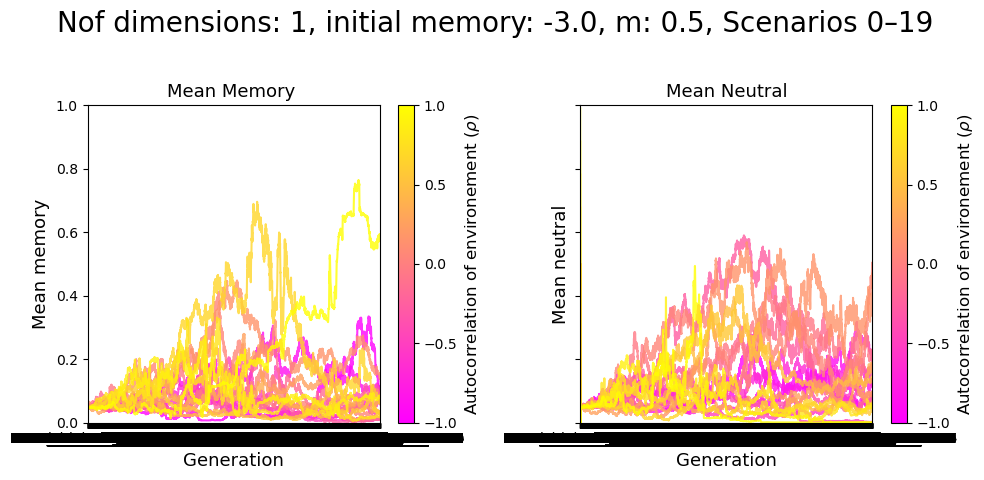

KeyboardInterrupt: 

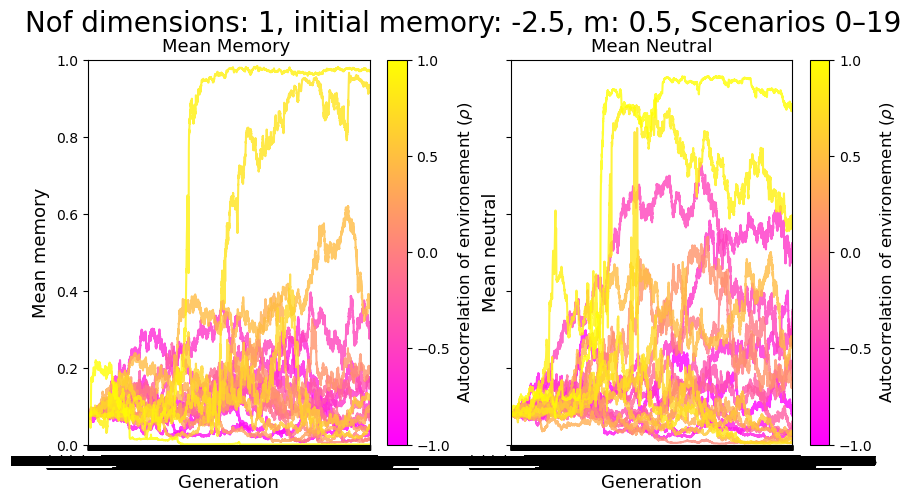

In [37]:
rho_sp_meanmem= rho_sp_meanmem.groupby(['ms','initial_mem'])
rho_sp_meanneu = rho_sp_meanneu.groupby(['ms','initial_mem'])
rho_sp_epi_fitness = rho_sp_epi_fitness.groupby(['ms','initial_mem'])
rho_sp_gen_fitness = rho_sp_gen_fitness.groupby(['ms','initial_mem'])

start =0

# Normalize rho range → [0, 1]

norm_rho = mcolors.Normalize(vmin=-1, vmax=1)
norm_m = mcolors.Normalize(vmin=0.5, vmax=1)
cmap_rho = cm.get_cmap("spring")
cmap_m = cm.get_cmap("cividis")
nof_dims ='1'
gens = np.arange(1, maxgen + 1)   #Proper x-axis

# Create figure once (outside loop)
# Loop over scenarios

for data_mem, data_neu in zip(rho_sp_meanmem, rho_sp_meanneu):
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
    
    initial_mem = data_mem[0][1]
    m= data_mem[0][0]
    memory_data = data_mem[1]
    neutral_data = data_neu[1]
    
    for i in range(len(memory_data)):
        
        rho = memory_data.iloc[i,0]           # pick rho for this scenario
       
        
        color_rho = cmap_rho(norm_rho(rho))       # convert rho → color
       
            
        ax[0].plot(gens,memory_data.iloc[i, 3:], 
                    color=color_rho, 
                    alpha=0.8)
        ax[1].plot(neutral_data.iloc[i, :], color=color_rho, alpha=0.8)

    # Axis formatting
    ax[0].set_title("Mean Memory ", fontsize=13)
    ax[0].set_ylabel("Mean memory", fontsize=13)
    ax[0].set_xlabel("Generation",  fontsize=13)
    ax[0].set_xlim(1, maxgen)
    ax[0].set_ylim(0, 1)

    ax[1].set_title("Mean Neutral", fontsize=13)
    ax[1].set_ylabel("Mean neutral",  fontsize=13)
    ax[1].set_xlabel("Generation", fontsize=13)
    ax[1].set_xlim(1, maxgen)
    ax[1].set_ylim(0, 1)
        
        
    #  Add a colorbar based on rho values
    sm = cm.ScalarMappable(cmap=cmap_rho, norm=norm_rho)
    sm.set_array([])  # required
        
    cbar1 = fig.colorbar(sm, ax=ax[0], label=rf"Autocorrelation of environement ($\rho$)", ticks=[-1, -0.5, 0,  0.5,  1.0])
    cbar1.set_label(rf"Autocorrelation of environement ($\rho$)", fontsize=12)
    cbar1 = fig.colorbar(sm, ax=ax[1], label=rf"Autocorrelation of environement ($\rho$)", ticks=[-1, -0.5, 0,  0.5,  1.0])
    cbar1.set_label(rf"Autocorrelation of environement ($\rho$)", fontsize=12)

    sm = cm.ScalarMappable(cmap=cmap_m, norm=norm_m)
    sm.set_array([])  # required

    fig.suptitle(f"Nof dimensions: {nof_dims}, initial memory: {initial_mem}, m: {m}, Scenarios {start}–{len(memory_data) - 1}", fontsize=20)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

### 1 Dimension, heat maps of starting point vs Autocorrelation at 3 different mean times spent

/tmp/ipykernel_4556/644671427.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_rho = cm.get_cmap("spring")
/tmp/ipykernel_4556/644671427.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_m = cm.get_cmap("cividis")


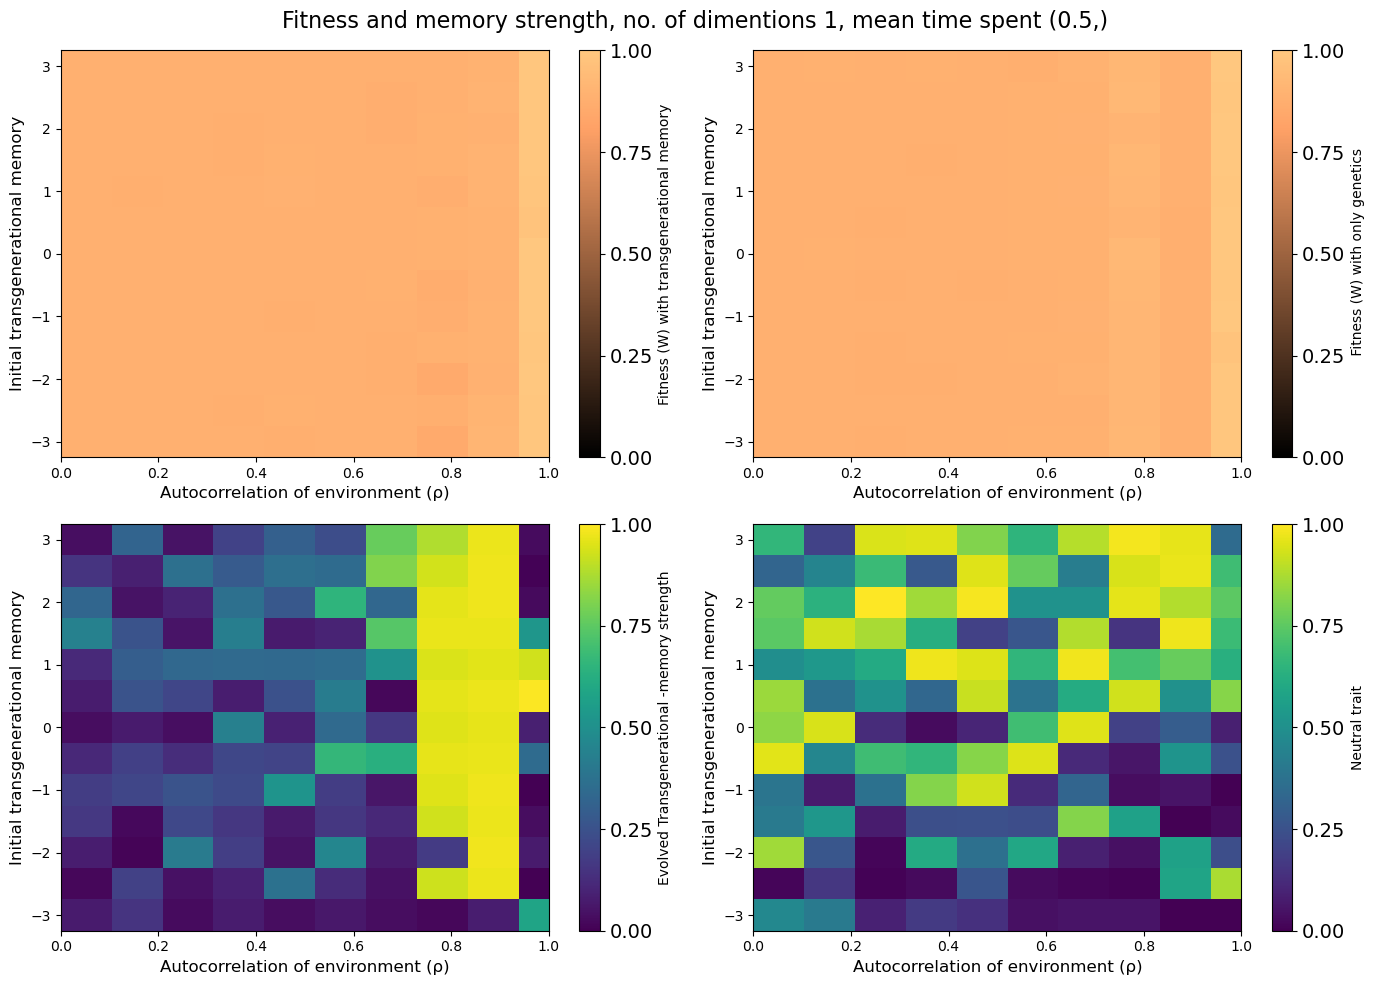

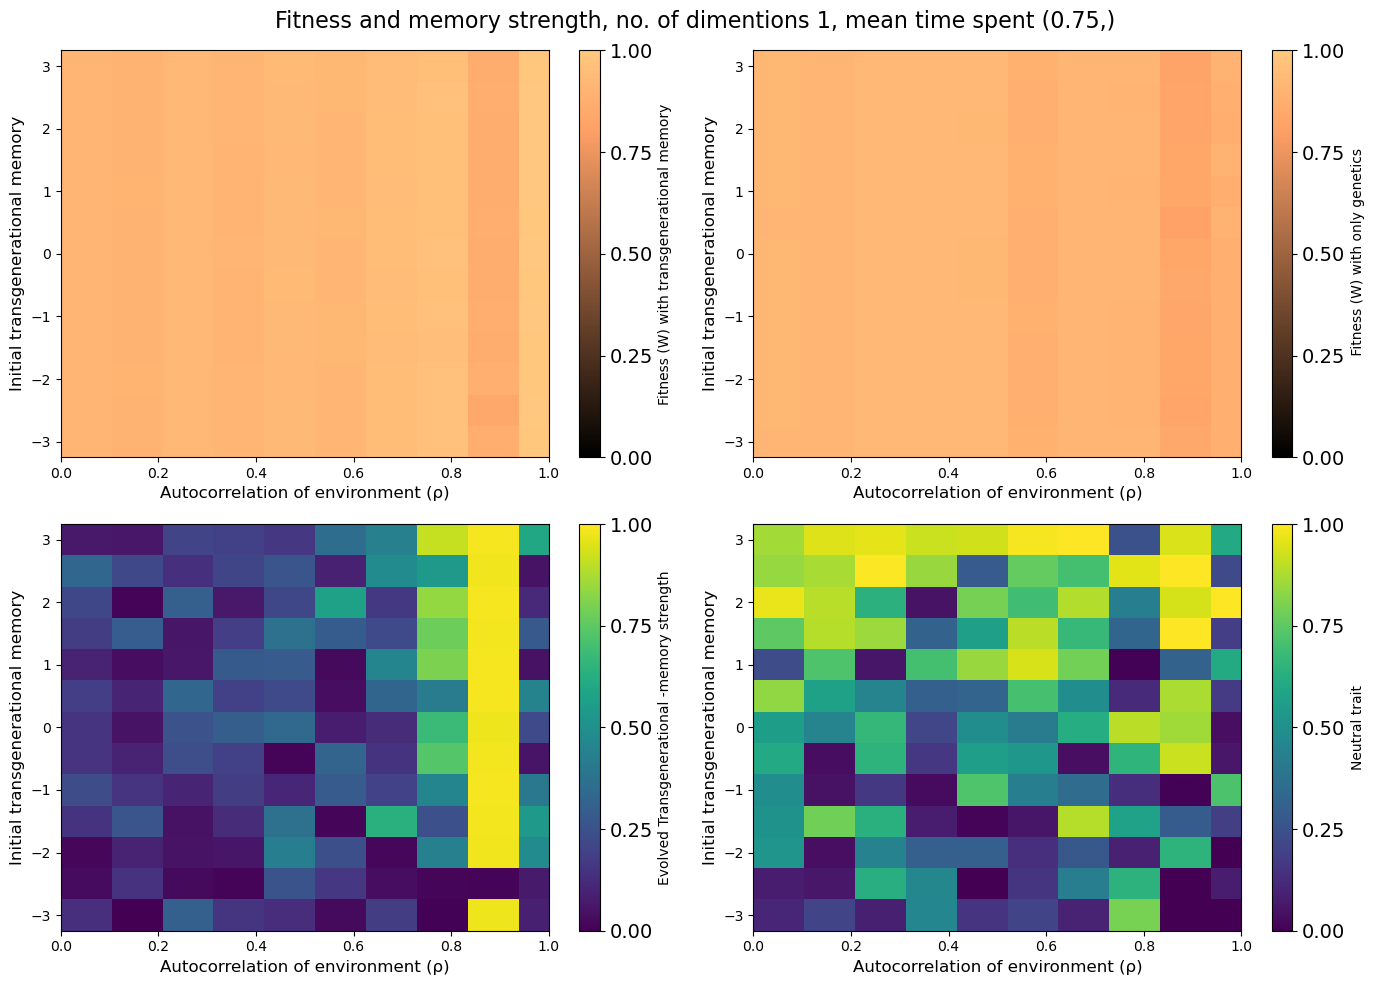

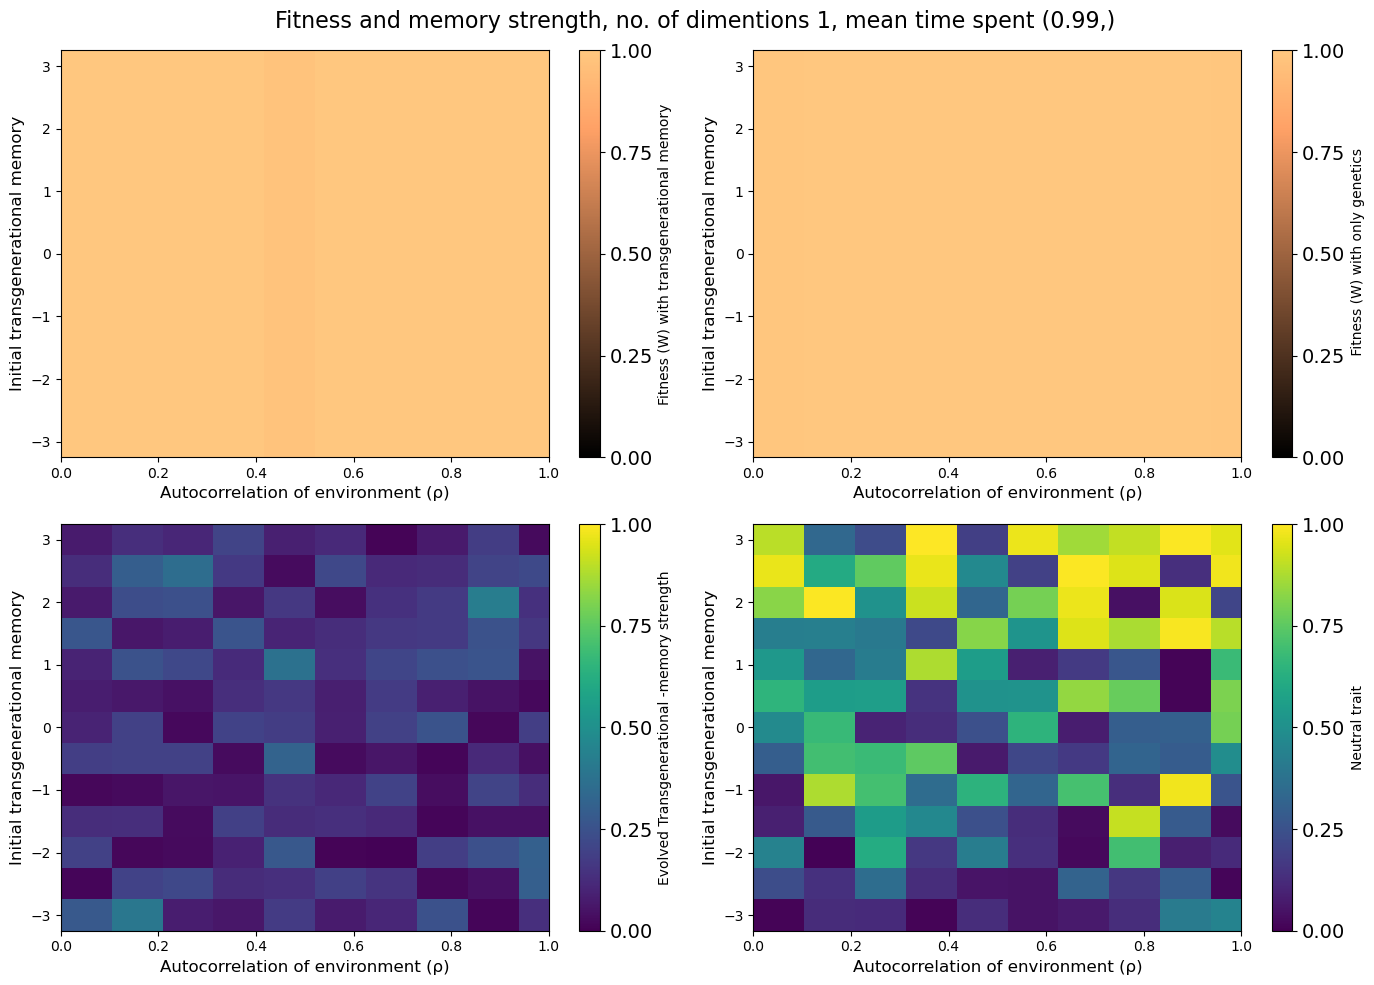

In [94]:
start =0
rho_sp_meanmem= pd.DataFrame(np.column_stack([rho_values, m_vals, initial_memory, meanmemory_p])).groupby([1])
rho_sp_meanneu = pd.DataFrame(np.column_stack([rho_values, m_vals, initial_memory, meanneutral_p])).groupby([1])
rho_sp_epi_fitness = pd.DataFrame(np.column_stack([rho_values,m_vals, initial_memory, fitness_epi])).groupby([1])
rho_sp_gen_fitness = pd.DataFrame(np.column_stack([rho_values,m_vals, initial_memory, fitness_gen])).groupby([1])

# Normalize rho range → [0, 1]

norm_rho = mcolors.Normalize(vmin=-1, vmax=1)
norm_m = mcolors.Normalize(vmin=0.5, vmax=1)
cmap_rho = cm.get_cmap("spring")
cmap_m = cm.get_cmap("cividis")

gens = np.arange(1, maxgen + 1)   #Proper x-axis
nof_dims =1
# Create figure once (outside loop)
# Loop over scenarios

for data_mem, data_neu, data_mem_fit, data_gen_fit in zip(rho_sp_meanmem, rho_sp_meanneu, rho_sp_epi_fitness, rho_sp_gen_fitness):


    m = data_mem[0]
    memory_data = data_mem[1]
    neutral_data = data_neu[1]
    memory_fitness_data = data_mem_fit[1]
    gen_fitness_data = data_gen_fit[1]
    
    df = pd.DataFrame({
        
    'rho': memory_data.iloc[:,0],
    'm': memory_data.iloc[:,1],
    'initial_mem': data_mem[1].iloc[:,2],
    'fitness':np.mean(memory_fitness_data.iloc[:,-50:], axis=1),
    'epi_mem_p': np.mean(memory_data.iloc[:,-50:], axis=1),
    'neutral_trait_p' : np.mean(neutral_data.iloc[:,-50:], axis=1 )
    })
    
    df_gen = pd.DataFrame({ 'rho': memory_data.iloc[:,0], 
                           'm': memory_data.iloc[:,1],
                           'initial_mem': data_mem[1].iloc[:,2],
        'fitness':np.mean(gen_fitness_data.iloc[:,-50:], axis=1)
        })
    
    
    fig, ax = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"Fitness and memory strength, no. of dimentions {nof_dims}, mean time spent {m}", fontsize=16)
    fig.subplots_adjust(top=0.90)   # more space for the suptitle
    cmap1 = plt.cm.copper.copy()  # copy to modify safely
    cmap1.set_bad(color='gray')    # gray for masked values
    norm = mcolors.Normalize(vmin=0.0, vmax=1.0)  # consistent color range
        
    cmap2 = plt.cm.viridis.copy()  # copy to modify safely
    cmap2.set_bad(color='gray')    # gray for masked values
    norm = mcolors.Normalize(vmin=0.0, vmax=1.0)  # consistent color range
        

    # --- (0,0) fitness ---
    pivoted_fitness = df.pivot_table(
            index='initial_mem',
            columns='rho',
            values='fitness'
        ).sort_index().sort_index(axis=1)

    pcm1 = ax[0,0].pcolormesh(
            pivoted_fitness.columns,
            pivoted_fitness.index,
            pivoted_fitness.values,
            cmap=cmap1,
            norm=norm,
            shading='auto'
        )
    cbar1 = fig.colorbar(pcm1, ax=ax[0,0], label='Fitness (W) with transgenerational memory', 
                            ticks=[0.0, 0.25, 0.5, 0.75, 1.0])
    cbar1.ax.tick_params(labelsize=14)

    ax[0,0].set_ylabel('mean time spent in environment A (m)', fontsize=12)
    ax[0,0].set_xlim(0,1)
    ax[0,0].set_ylabel('Initial transgenerational memory', fontsize=12)
    ax[0,0].set_xlabel('Autocorrelation of environment (ρ)', fontsize=12)


        # --- (0,1) genetic fitness ---
    pivoted_gen = df_gen.pivot_table(
            index='initial_mem',
            columns='rho',
            values='fitness'
        ).sort_index().sort_index(axis=1)

    pcm2 = ax[0,1].pcolormesh(
            pivoted_gen.columns,
            pivoted_gen.index,
            pivoted_gen.values,
            cmap=cmap1,
            norm=norm,
            shading='auto'
        )
    cbar2 = fig.colorbar(pcm2, ax=ax[0,1], 
                            label=' Fitness (W) with only genetics',
                            ticks=[0.0, 0.25, 0.5, 0.75, 1.0])
    cbar2.ax.tick_params(labelsize=14)

    ax[0,1].set_ylabel('mean time spent in environment A (m)', fontsize=12)
    ax[0,1].set_xlim(0,1)
    ax[0,1].set_ylabel('Initial transgenerational memory', fontsize=12)
    ax[0,1].set_xlabel('Autocorrelation of environment (ρ)', fontsize=12)

        # --- (1,0) epimem ---
    pivoted_epi = df.pivot_table(
            index='initial_mem',
            columns='rho',
            values='epi_mem_p'
        ).sort_index().sort_index(axis=1)

    pcm3 = ax[1,0].pcolormesh(
            pivoted_epi.columns,
            pivoted_epi.index,
            pivoted_epi.values,
            cmap=cmap2,
            norm=norm,
            shading='auto'
        )
    cbar3 = fig.colorbar(pcm3, ax=ax[1,0], label=r'Evolved Transgenerational -memory strength',
                            ticks=[0, 0.25, 0.5, 0.75, 1.0])
    cbar3.ax.tick_params(labelsize=14)

    ax[1,0].set_ylabel('mean time spent in environment A (m)', fontsize=12)
    ax[1,0].set_xlim(0,1)
    ax[1,0].set_ylabel('Initial transgenerational memory', fontsize=12)
    ax[1,0].set_xlabel('Autocorrelation of environment (ρ)', fontsize=12)

        # --- (1,1) neutral ---
    pivoted_neutral = df.pivot_table(
            index='initial_mem',
            columns='rho',
            values='neutral_trait_p'
        ).sort_index().sort_index(axis=1)

    pcm4 = ax[1,1].pcolormesh(
            pivoted_neutral.columns,
            pivoted_neutral.index,
            pivoted_neutral.values,
            cmap=cmap2,
            norm=norm,
            shading='auto'
        )
    cbar4 = fig.colorbar(pcm4, ax=ax[1,1], label='Neutral trait',
                            ticks=[0.0, 0.25, 0.5, 0.75, 1.0])
    cbar4.ax.tick_params(labelsize=14)

    ax[1,1].set_ylabel('mean time spent in environment A (m)', fontsize=12)
    ax[1,1].set_xlim(0,1)
    ax[1,1].set_ylabel('Initial transgenerational memory', fontsize=12)
    ax[1,1].set_xlabel('Autocorrelation of environment (ρ)', fontsize=12)
            
            
    plt.tight_layout()
    plt.show()
        
    

### 5 Dimensions, heat maps of starting point vs Autocorrelation at 3 different mean times spent

#### Collect data from array with 5 dimensions

In [86]:
#Collect Dtaa
concatenated_results_epi = concatenated_results_dim5_epi
meanmemory_p = concatenated_results_epi['meanmemory_p'][:, :-1]
meanneutral_p = concatenated_results_epi['meanneutral_p'][:, :-1]
stdmemory_p = concatenated_results_epi['std_memory_p'][:, :-1]
stdneutral_p = concatenated_results_epi['std_neutral_p'][:, :-1]
stdmemory_p=concatenated_results_epi['std_memory_p'][:, :-1]
stdneutral_p=concatenated_results_epi['std_neutral_p'][:, :-1]
fitness_epi= concatenated_results_epi['meanw'][:, :-1]
fitness_gen = concatenated_results_dim5_og['meanw'][:, :-1]

nof_scenarios = (meanmemory_p.shape[0] -1)
maxgen = meanmemory_p.shape[1]

#collects rhos and ms
rho_values = concatenated_results_epi['rho_m_alpha_beta'][:, 0]   # one rho per scenario
m_vals = concatenated_results_epi['rho_m_alpha_beta'][:, 1]
initial_memory = concatenated_results_epi['initial_memory_array'][:, 0]
nof_dims = '5'

rho_sp_meanmem= pd.DataFrame(np.column_stack([rho_values, m_vals, initial_memory, meanmemory_p])).groupby([1])
rho_sp_meanneu = pd.DataFrame(np.column_stack([rho_values, m_vals, initial_memory, meanneutral_p])).groupby([1])
rho_sp_epi_fitness = pd.DataFrame(np.column_stack([rho_values,m_vals, initial_memory, fitness_epi])).groupby([1])
rho_sp_gen_fitness = pd.DataFrame(np.column_stack([rho_values,m_vals, initial_memory, fitness_gen])).groupby([1])


/tmp/ipykernel_4556/3900099051.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_rho = cm.get_cmap("spring")
/tmp/ipykernel_4556/3900099051.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_m = cm.get_cmap("cividis")


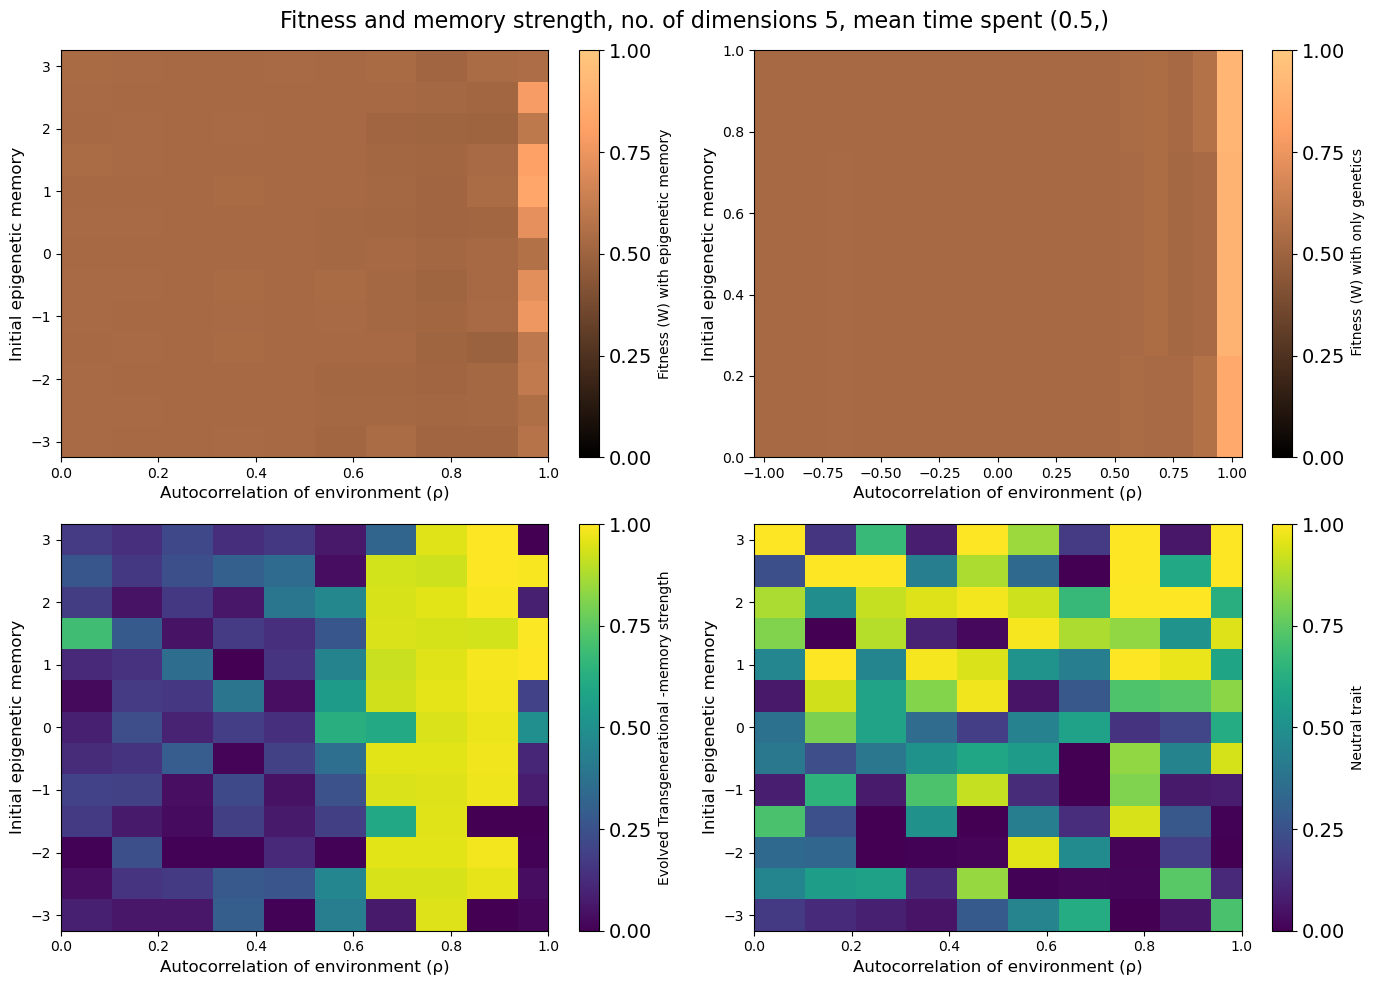

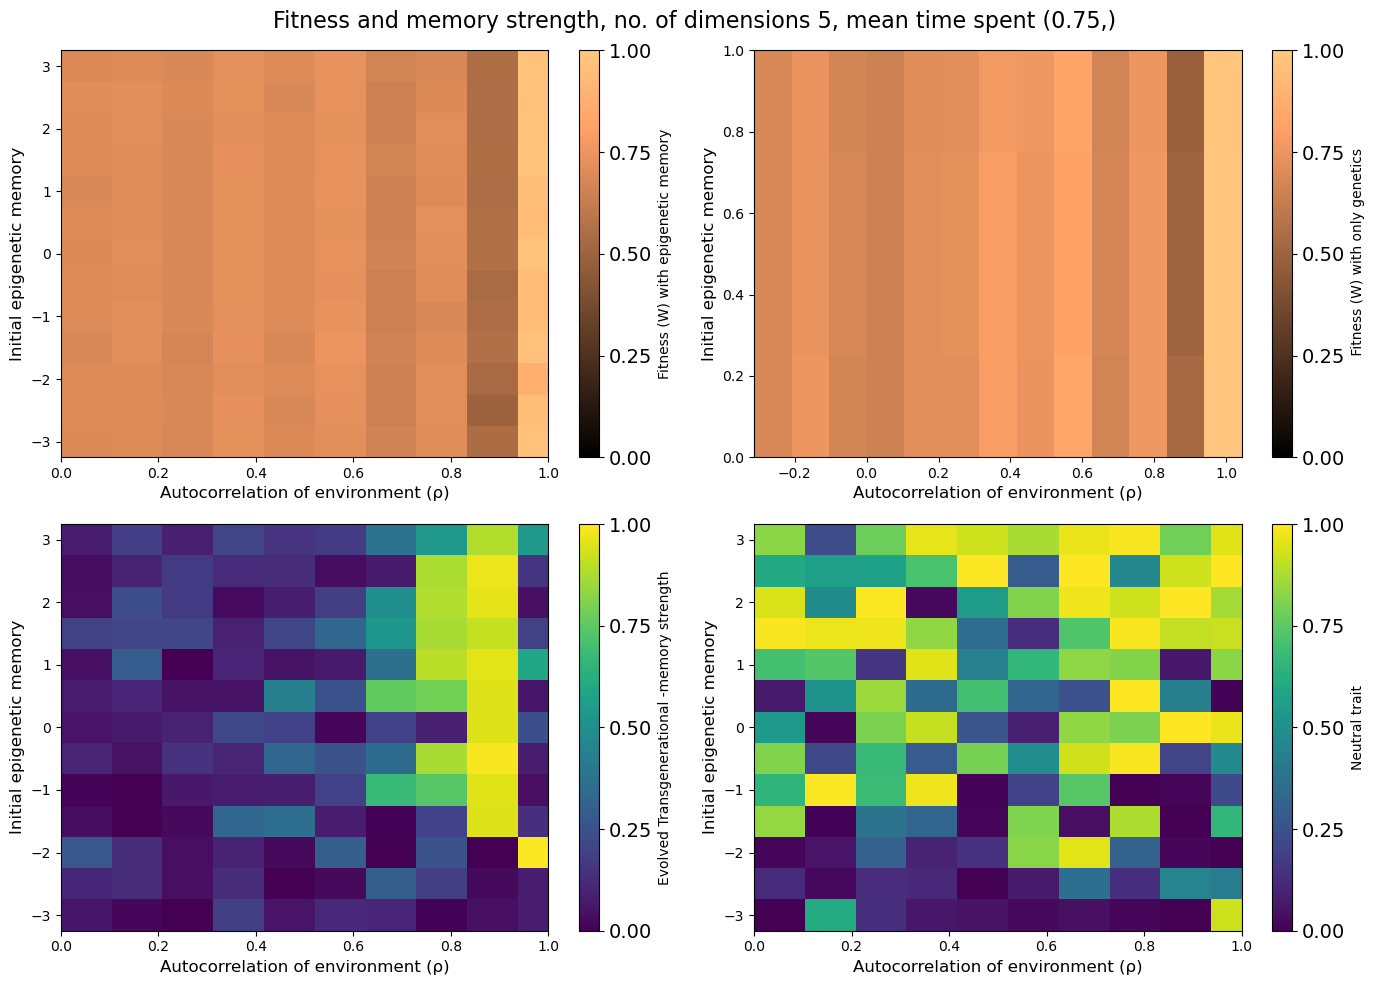

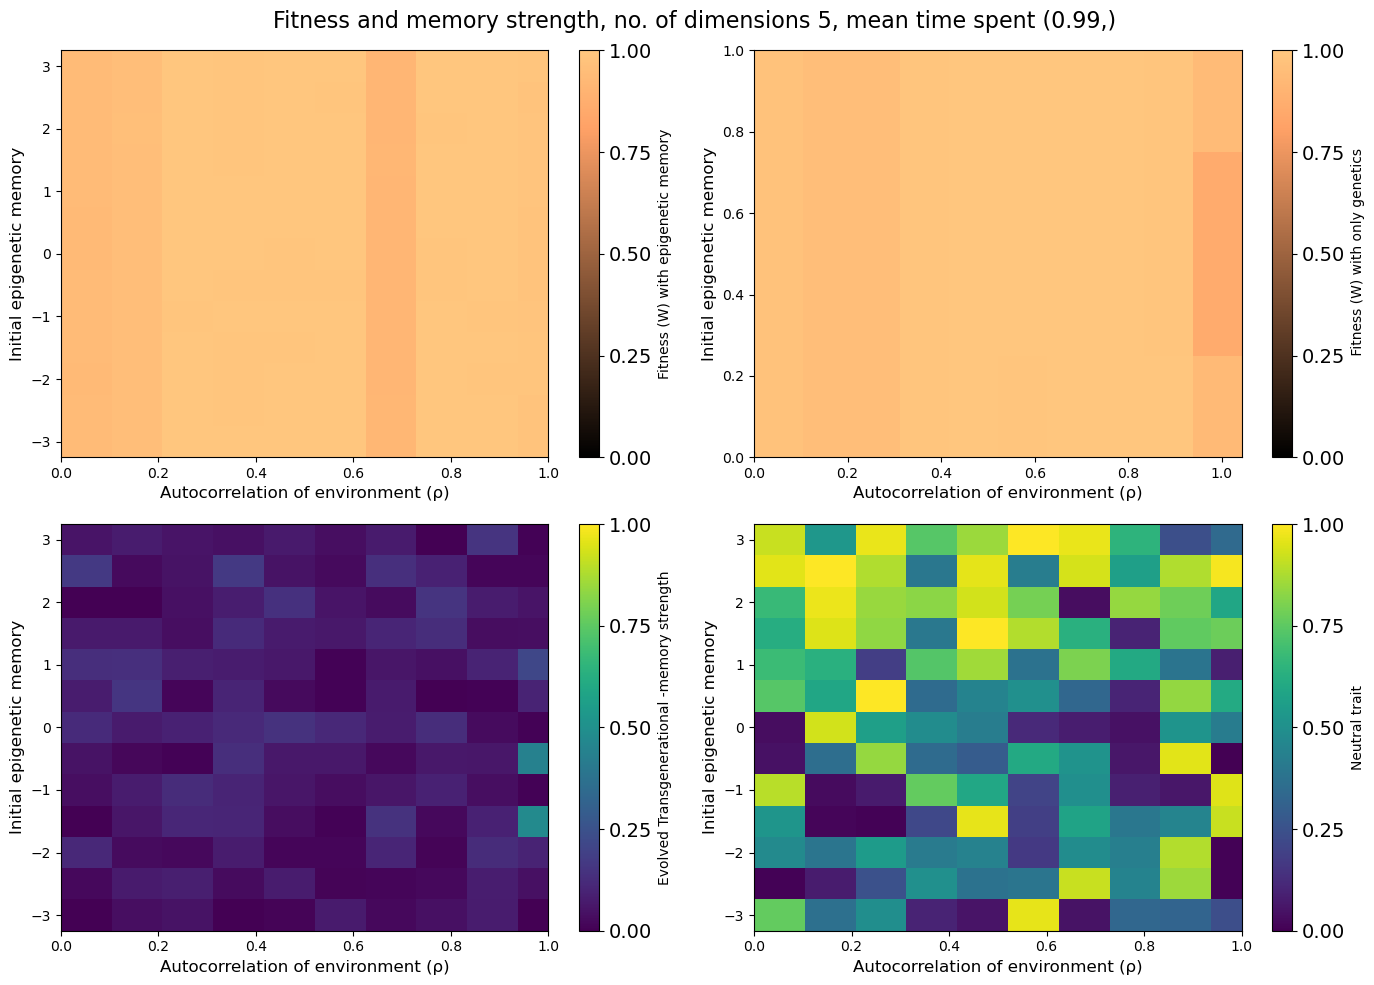

In [ ]:

# Normalize rho range → [0, 1]

norm_rho = mcolors.Normalize(vmin=-1, vmax=1)
norm_m = mcolors.Normalize(vmin=0.5, vmax=1)
cmap_rho = cm.get_cmap("spring")
cmap_m = cm.get_cmap("cividis")

gens = np.arange(1, maxgen + 1)   #Proper x-axis

# Create figure once (outside loop)
# Loop over scenarios

for data_mem, data_neu, data_mem_fit, data_gen_fit in zip(rho_sp_meanmem, rho_sp_meanneu, rho_sp_epi_fitness, rho_sp_gen_fitness):


    m = data_mem[0]
    memory_data = data_mem[1]
    neutral_data = data_neu[1]
    memory_fitness_data = data_mem_fit[1]
    gen_fitness_data = data_gen_fit[1]
    
    df = pd.DataFrame({
        
    'rho': memory_data.iloc[:,0],
    'm': memory_data.iloc[:,1],
    'initial_mem': data_mem[1].iloc[:,2],
    'fitness':np.mean(memory_fitness_data.iloc[:,-50:], axis=1),
    'epi_mem_p': np.mean(memory_data.iloc[:,-50:], axis=1),
    'neutral_trait_p' : np.mean(neutral_data.iloc[:,-50:], axis=1 )
    })
    
    df_gen = pd.DataFrame({ 'rho': memory_data.iloc[:,0], 
                           'm': memory_data.iloc[:,1],
                           'initial_mem': data_mem[1].iloc[:,2],
        'fitness':np.mean(gen_fitness_data.iloc[:,-50:], axis=1)
        })
    
    
    fig, ax = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"Fitness and memory strength, no. of dimensions {nof_dims}, mean time spent {m}", fontsize=16)
    fig.subplots_adjust(top=0.90)   # more space for the suptitle
    cmap1 = plt.cm.copper.copy()  # copy to modify safely
    cmap1.set_bad(color='gray')    # gray for masked values
    norm = mcolors.Normalize(vmin=0.0, vmax=1.0)  # consistent color range
        
    cmap2 = plt.cm.viridis.copy()  # copy to modify safely
    cmap2.set_bad(color='gray')    # gray for masked values
    norm = mcolors.Normalize(vmin=0.0, vmax=1.0)  # consistent color range
        

    # --- (0,0) fitness ---
    pivoted_fitness = df.pivot_table(
            index='initial_mem',
            columns='rho',
            values='fitness'
        ).sort_index().sort_index(axis=1)

    pcm1 = ax[0,0].pcolormesh(
            pivoted_fitness.columns,
            pivoted_fitness.index,
            pivoted_fitness.values,
            cmap=cmap1,
            norm=norm,
            shading='auto'
        )
    cbar1 = fig.colorbar(pcm1, ax=ax[0,0], label='Fitness (W) with transgenerational memory', 
                            ticks=[0.0, 0.25, 0.5, 0.75, 1.0])
    cbar1.ax.tick_params(labelsize=14)

    ax[0,0].set_ylabel('mean time spent in environment A (m)', fontsize=12)
    ax[0,0].set_xlim(0,1)
    ax[0,0].set_ylabel('Initial transgenerational memory', fontsize=12)
    ax[0,0].set_xlabel('Autocorrelation of environment (ρ)', fontsize=12)


        # --- (0,1) genetic fitness ---
    pivoted_gen = df_gen.pivot_table(
            index='initial_mem',
            columns='rho',
            values='fitness'
        ).sort_index().sort_index(axis=1)

    pcm2 = ax[0,1].pcolormesh(
            pivoted_gen.columns,
            pivoted_gen.index,
            pivoted_gen.values,
            cmap=cmap1,
            norm=norm,
            shading='auto'
        )
    cbar2 = fig.colorbar(pcm2, ax=ax[0,1], 
                            label=' Fitness (W) with only genetics',
                            ticks=[0.0, 0.25, 0.5, 0.75, 1.0])
    cbar2.ax.tick_params(labelsize=14)

    ax[0,1].set_ylabel('mean time spent in environment A (m)', fontsize=12)
    ax[0,1].set_ylim(0,1)
    ax[0,1].set_ylabel('Initial transgenerational memory', fontsize=12)
    ax[0,1].set_xlabel('Autocorrelation of environment (ρ)', fontsize=12)

        # --- (1,0) epimem ---
    pivoted_epi = df.pivot_table(
            index='initial_mem',
            columns='rho',
            values='epi_mem_p'
        ).sort_index().sort_index(axis=1)

    pcm3 = ax[1,0].pcolormesh(
            pivoted_epi.columns,
            pivoted_epi.index,
            pivoted_epi.values,
            cmap=cmap2,
            norm=norm,
            shading='auto'
        )
    cbar3 = fig.colorbar(pcm3, ax=ax[1,0], label=r'Evolved Transgenerational -memory strength',
                            ticks=[0, 0.25, 0.5, 0.75, 1.0])
    cbar3.ax.tick_params(labelsize=14)

    ax[1,0].set_ylabel('mean time spent in environment A (m)', fontsize=12)
    ax[1,0].set_xlim(0,1)
    ax[1,0].set_ylabel('Initial transgenerational memory', fontsize=12)
    ax[1,0].set_xlabel('Autocorrelation of environment (ρ)', fontsize=12)

        # --- (1,1) neutral ---
    pivoted_neutral = df.pivot_table(
            index='initial_mem',
            columns='rho',
            values='neutral_trait_p'
        ).sort_index().sort_index(axis=1)

    pcm4 = ax[1,1].pcolormesh(
            pivoted_neutral.columns,
            pivoted_neutral.index,
            pivoted_neutral.values,
            cmap=cmap2,
            norm=norm,
            shading='auto'
        )
    cbar4 = fig.colorbar(pcm4, ax=ax[1,1], label='Neutral trait',
                            ticks=[0.0, 0.25, 0.5, 0.75, 1.0])
    cbar4.ax.tick_params(labelsize=14)

    ax[1,1].set_ylabel('mean time spent in environment A (m)', fontsize=12)
    ax[1,1].set_xlim(0,1)
    ax[1,1].set_ylabel('Initial transgenerational memory', fontsize=12)
    ax[1,1].set_xlabel('Autocorrelation of environment (ρ)', fontsize=12)
            
            
    plt.tight_layout()
    plt.show()
        
    

###  10 dimentions

In [4]:
keys = list(dim1_epi[0].keys())

concatenated_results_dim10_epi = {}


for k in keys:
        concatenated_results_dim10_epi[k] = np.vstack([r[k] for r in dim10_epi])
        

concatenated_results_dim10_og = {}


for k in keys:
        concatenated_results_dim10_og[k] = np.vstack([r[k] for r in dim10_og])
        


In [5]:
#Collect Dtaa
concatenated_results_epi = concatenated_results_dim10_epi
meanmemory_p = concatenated_results_epi['meanmemory_p'][:, :-1]
meanneutral_p = concatenated_results_epi['meanneutral_p'][:, :-1]
stdmemory_p = concatenated_results_epi['std_memory_p'][:, :-1]
stdneutral_p = concatenated_results_epi['std_neutral_p'][:, :-1]
stdmemory_p=concatenated_results_epi['std_memory_p'][:, :-1]
stdneutral_p=concatenated_results_epi['std_neutral_p'][:, :-1]
fitness_epi= concatenated_results_epi['meanw'][:, :-1]
fitness_gen = concatenated_results_dim10_og['meanw'][:, :-1]

nof_scenarios = (meanmemory_p.shape[0] -1)
maxgen = meanmemory_p.shape[1]

#collects rhos and ms
rho_values = concatenated_results_epi['rho_m_alpha_beta'][:, 0]   # one rho per scenario
m_vals = concatenated_results_epi['rho_m_alpha_beta'][:, 1]
initial_memory = concatenated_results_epi['initial_memory_array'][:, 0]
nof_dims = '5'

rho_sp_meanmem= pd.DataFrame(np.column_stack([rho_values, m_vals, initial_memory, meanmemory_p])).groupby([1])
rho_sp_meanneu = pd.DataFrame(np.column_stack([rho_values, m_vals, initial_memory, meanneutral_p])).groupby([1])
rho_sp_epi_fitness = pd.DataFrame(np.column_stack([rho_values,m_vals, initial_memory, fitness_epi])).groupby([1])
rho_sp_gen_fitness = pd.DataFrame(np.column_stack([rho_values,m_vals, initial_memory, fitness_gen])).groupby([1])


/tmp/ipykernel_10271/672802766.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_rho = cm.get_cmap("spring")
/tmp/ipykernel_10271/672802766.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_m = cm.get_cmap("cividis")


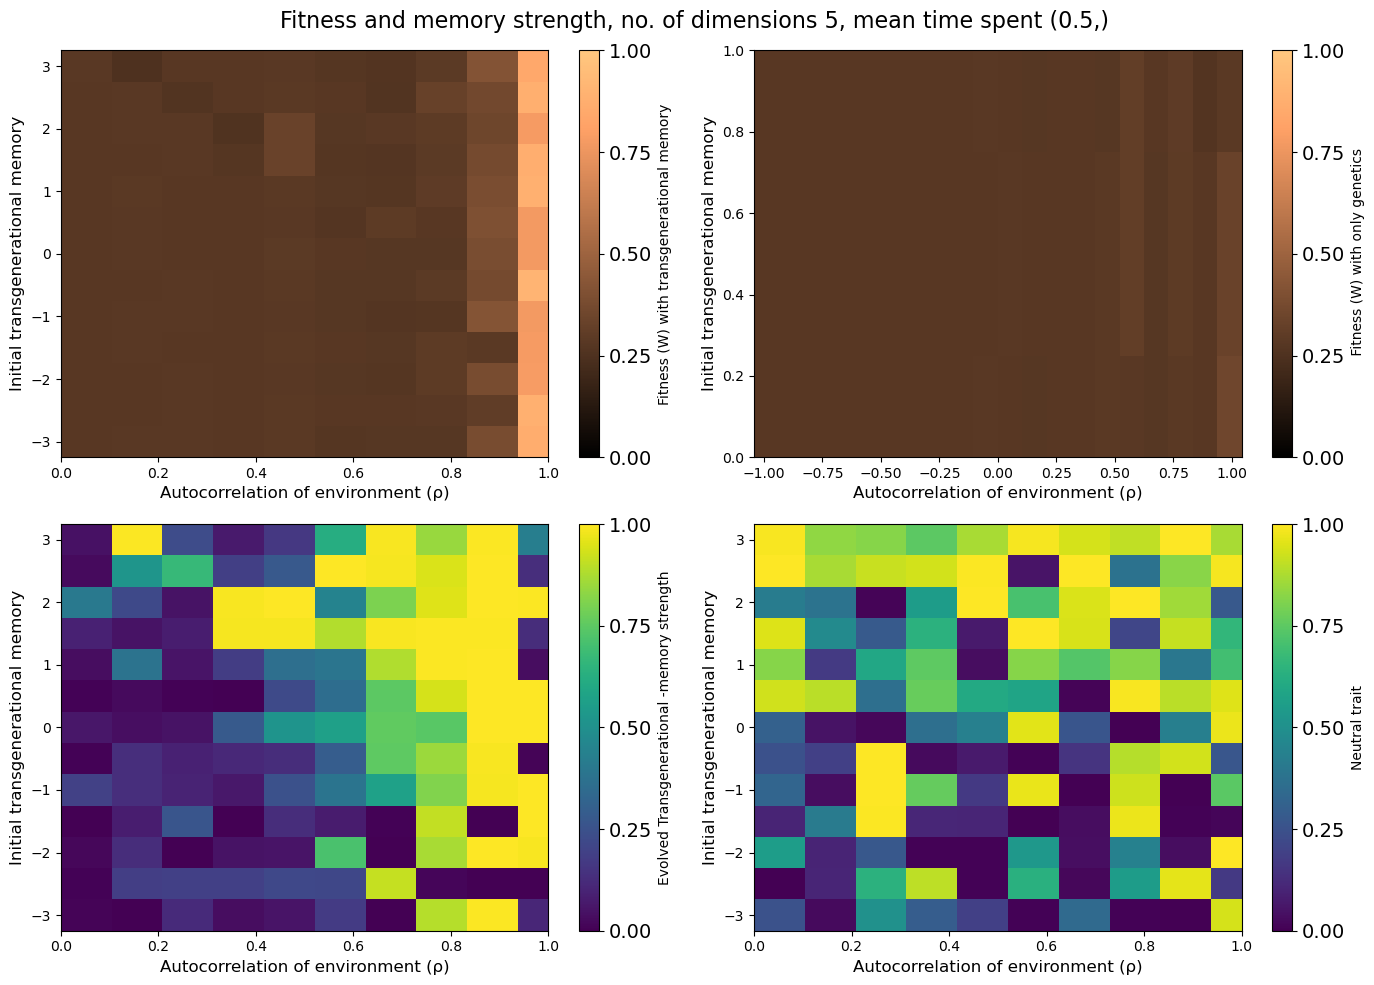

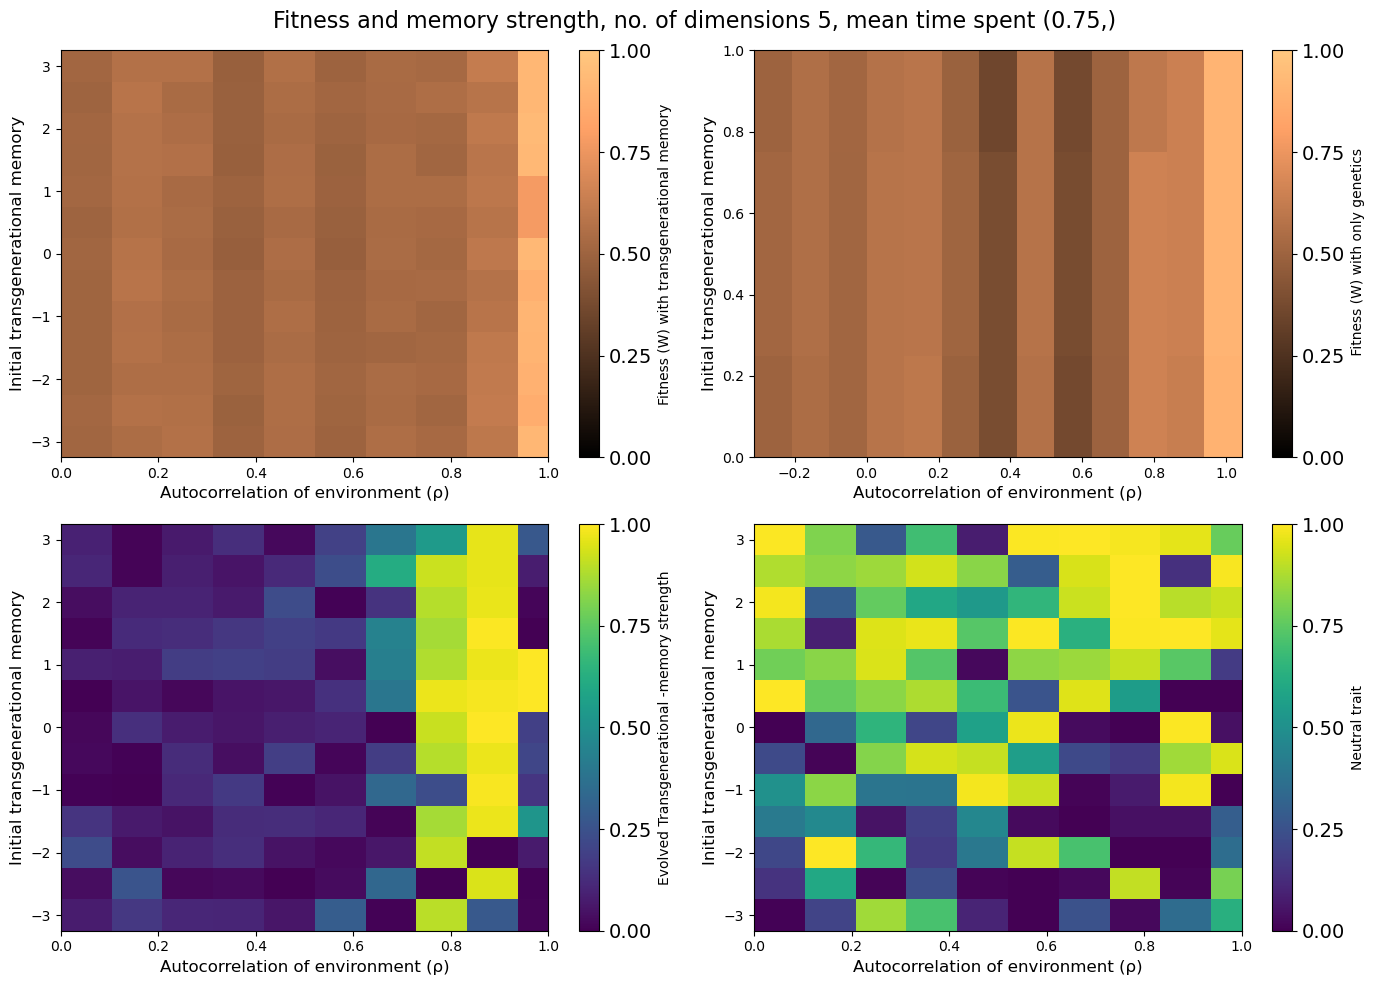

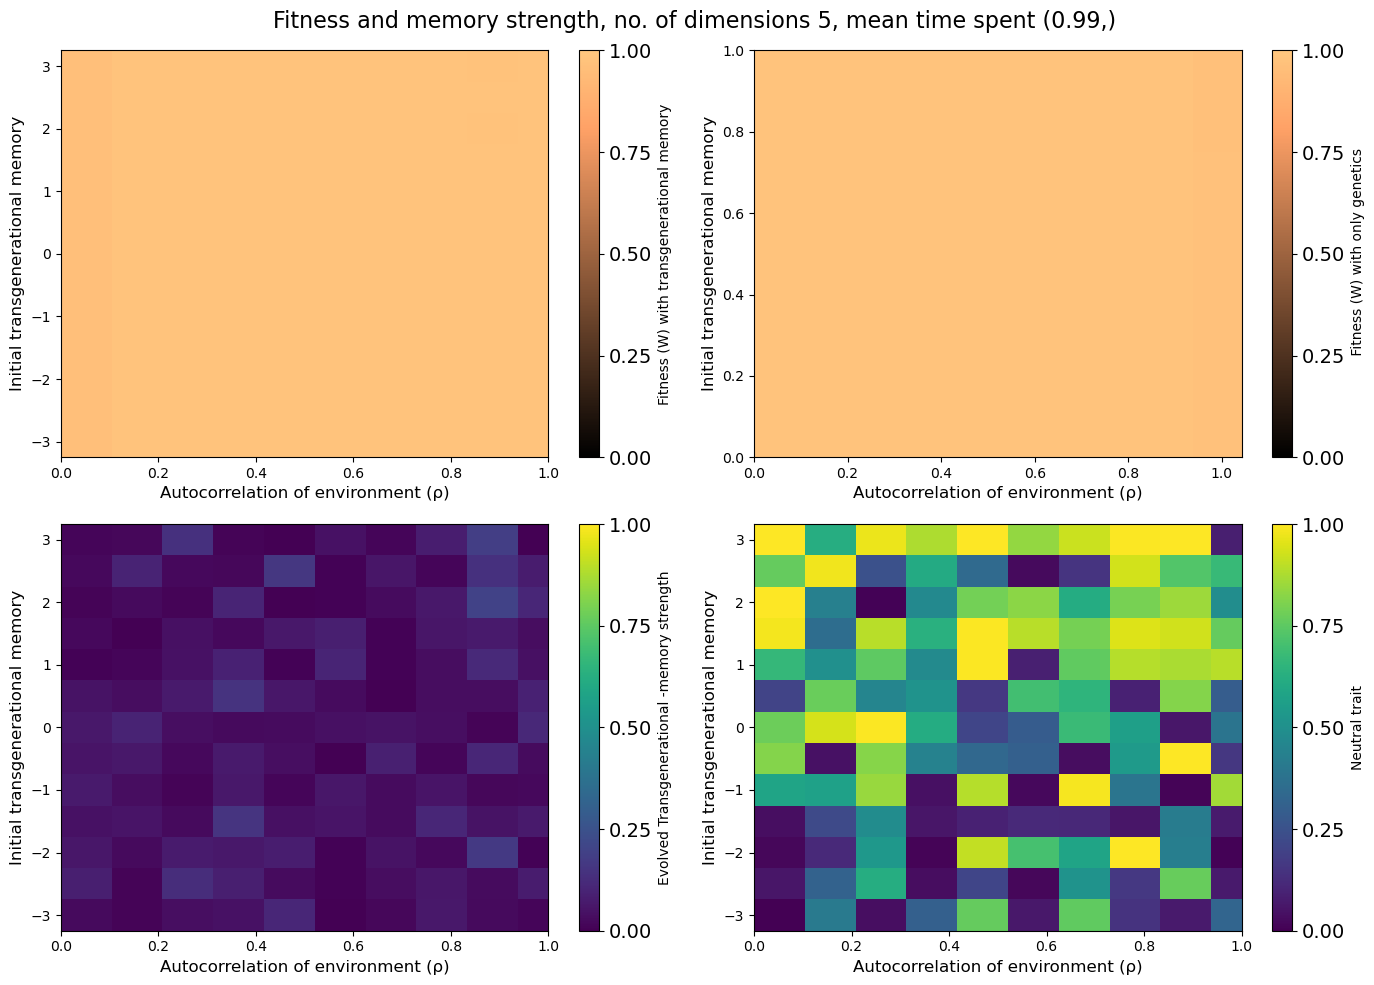

In [6]:
# Normalize rho range → [0, 1]

norm_rho = mcolors.Normalize(vmin=-1, vmax=1)
norm_m = mcolors.Normalize(vmin=0.5, vmax=1)
cmap_rho = cm.get_cmap("spring")
cmap_m = cm.get_cmap("cividis")

gens = np.arange(1, maxgen + 1)   #Proper x-axis

# Create figure once (outside loop)
# Loop over scenarios

for data_mem, data_neu, data_mem_fit, data_gen_fit in zip(rho_sp_meanmem, rho_sp_meanneu, rho_sp_epi_fitness, rho_sp_gen_fitness):


    m = data_mem[0]
    memory_data = data_mem[1]
    neutral_data = data_neu[1]
    memory_fitness_data = data_mem_fit[1]
    gen_fitness_data = data_gen_fit[1]
    
    df = pd.DataFrame({
        
    'rho': memory_data.iloc[:,0],
    'm': memory_data.iloc[:,1],
    'initial_mem': data_mem[1].iloc[:,2],
    'fitness':np.mean(memory_fitness_data.iloc[:,-50:], axis=1),
    'epi_mem_p': np.mean(memory_data.iloc[:,-50:], axis=1),
    'neutral_trait_p' : np.mean(neutral_data.iloc[:,-50:], axis=1 )
    })
    
    df_gen = pd.DataFrame({ 'rho': memory_data.iloc[:,0], 
                           'm': memory_data.iloc[:,1],
                           'initial_mem': data_mem[1].iloc[:,2],
        'fitness':np.mean(gen_fitness_data.iloc[:,-50:], axis=1)
        })
    
    
    fig, ax = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"Fitness and memory strength, no. of dimensions {nof_dims}, mean time spent {m}", fontsize=16)
    fig.subplots_adjust(top=0.90)   # more space for the suptitle
    cmap1 = plt.cm.copper.copy()  # copy to modify safely
    cmap1.set_bad(color='gray')    # gray for masked values
    norm = mcolors.Normalize(vmin=0.0, vmax=1.0)  # consistent color range
        
    cmap2 = plt.cm.viridis.copy()  # copy to modify safely
    cmap2.set_bad(color='gray')    # gray for masked values
    norm = mcolors.Normalize(vmin=0.0, vmax=1.0)  # consistent color range
        

    # --- (0,0) fitness ---
    pivoted_fitness = df.pivot_table(
            index='initial_mem',
            columns='rho',
            values='fitness'
        ).sort_index().sort_index(axis=1)

    pcm1 = ax[0,0].pcolormesh(
            pivoted_fitness.columns,
            pivoted_fitness.index,
            pivoted_fitness.values,
            cmap=cmap1,
            norm=norm,
            shading='auto'
        )
    cbar1 = fig.colorbar(pcm1, ax=ax[0,0], label='Fitness (W) with transgenerational memory', 
                            ticks=[0.0, 0.25, 0.5, 0.75, 1.0])
    cbar1.ax.tick_params(labelsize=14)

    ax[0,0].set_ylabel('mean time spent in environment A (m)', fontsize=12)
    ax[0,0].set_xlim(0,1)
    ax[0,0].set_ylabel('Initial transgenerational memory', fontsize=12)
    ax[0,0].set_xlabel('Autocorrelation of environment (ρ)', fontsize=12)


        # --- (0,1) genetic fitness ---
    pivoted_gen = df_gen.pivot_table(
            index='initial_mem',
            columns='rho',
            values='fitness'
        ).sort_index().sort_index(axis=1)

    pcm2 = ax[0,1].pcolormesh(
            pivoted_gen.columns,
            pivoted_gen.index,
            pivoted_gen.values,
            cmap=cmap1,
            norm=norm,
            shading='auto'
        )
    cbar2 = fig.colorbar(pcm2, ax=ax[0,1], 
                            label=' Fitness (W) with only genetics',
                            ticks=[0.0, 0.25, 0.5, 0.75, 1.0])
    cbar2.ax.tick_params(labelsize=14)

    ax[0,1].set_ylabel('mean time spent in environment A (m)', fontsize=12)
    ax[0,1].set_ylim(0,1)
    ax[0,1].set_ylabel('Initial transgenerational memory', fontsize=12)
    ax[0,1].set_xlabel('Autocorrelation of environment (ρ)', fontsize=12)

        # --- (1,0) epimem ---
    pivoted_epi = df.pivot_table(
            index='initial_mem',
            columns='rho',
            values='epi_mem_p'
        ).sort_index().sort_index(axis=1)

    pcm3 = ax[1,0].pcolormesh(
            pivoted_epi.columns,
            pivoted_epi.index,
            pivoted_epi.values,
            cmap=cmap2,
            norm=norm,
            shading='auto'
        )
    cbar3 = fig.colorbar(pcm3, ax=ax[1,0], label=r'Evolved Transgenerational -memory strength',
                            ticks=[0, 0.25, 0.5, 0.75, 1.0])
    cbar3.ax.tick_params(labelsize=14)

    ax[1,0].set_ylabel('mean time spent in environment A (m)', fontsize=12)
    ax[1,0].set_xlim(0,1)
    ax[1,0].set_ylabel('Initial transgenerational memory', fontsize=12)
    ax[1,0].set_xlabel('Autocorrelation of environment (ρ)', fontsize=12)

        # --- (1,1) neutral ---
    pivoted_neutral = df.pivot_table(
            index='initial_mem',
            columns='rho',
            values='neutral_trait_p'
        ).sort_index().sort_index(axis=1)

    pcm4 = ax[1,1].pcolormesh(
            pivoted_neutral.columns,
            pivoted_neutral.index,
            pivoted_neutral.values,
            cmap=cmap2,
            norm=norm,
            shading='auto'
        )
    cbar4 = fig.colorbar(pcm4, ax=ax[1,1], label='Neutral trait',
                            ticks=[0.0, 0.25, 0.5, 0.75, 1.0])
    cbar4.ax.tick_params(labelsize=14)

    ax[1,1].set_ylabel('mean time spent in environment A (m)', fontsize=12)
    ax[1,1].set_xlim(0,1)
    ax[1,1].set_ylabel('Initial transgenerational memory', fontsize=12)
    ax[1,1].set_xlabel('Autocorrelation of environment (ρ)', fontsize=12)
            
            
    plt.tight_layout()
    plt.show()
        
    